In [1]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import hydra
import matplotlib.patches as mpatches

sns.set_theme()


In [2]:
import wandb
from dm_env import specs
import uuid
from collections import OrderedDict

from helpers import modulators

In [3]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="../", version_base=None)
cfg = hydra.compose(config_name="full_train_miniworld_slippery_fix")

In [4]:
cfg.logging.mode = "full_train_slippery_fix_ou"

In [6]:
if cfg.logging.mode == "full_train":
    experiment = cfg.domain.train.logging.experiment

elif cfg.logging.mode == "test":
    experiment = cfg.domain.test.logging.experiment

elif cfg.logging.mode == "pretrain":
    experiment = cfg.domain.pretrain.logging.experiment
elif cfg.logging.mode == "full_train_slippery":
    experiment = cfg.domain.train.logging.experiment + "_slippery"

elif cfg.logging.mode == "full_train_slippery_fix":
    experiment = cfg.domain.train.logging.experiment + "_slippery_fix"

elif cfg.logging.mode == "full_train_slippery_fix_non_periodic":
    experiment = cfg.domain.train.logging.experiment + "_slippery_fix_non_periodic"

elif cfg.logging.mode == "full_train_slippery_fix_ou":
    experiment = cfg.domain.train.logging.experiment + "_slippery_fix_ou"

else:
    raise ValueError("Invalid logging mode: {}".format(cfg.logging.mode))

In [7]:
moving_average_window = 10 # window size for moving average

In [8]:
print(experiment)

full_train_miniworld_slippery_fix_ou


In [9]:
api = wandb.Api()

project_name = "continual_rl" + "_" + cfg.logging.mode + "_" + experiment
print(project_name)
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

continual_rl_full_train_slippery_fix_ou_full_train_miniworld_slippery_fix_ou
num_of_runs: 65


In [10]:
for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["agent_feature_dim"] != 256:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/avg_episode_returns"])
    avg_episode_return = [
        row["eval/avg_episode_returns"] for row in avg_episode_returns_history
    ]

    avg_episode_length_history = run.scan_history(keys=["eval/avg_episode_length"])
    avg_episode_length = [
        row["eval/avg_episode_length"] for row in avg_episode_length_history
    ]

    steps_history = run.scan_history(keys=["eval/steps"])

    steps = [row["eval/steps"] for row in steps_history]

    task_history = run.scan_history(keys=["train/task"])
    task = [row["train/task"] for row in task_history]


    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue

    print("len(steps): ", len(steps))
    print("len(avg_episode_return): ", len(avg_episode_return))
    print("len(avg_episode_length): ", len(avg_episode_length))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/steps"] = steps
    temp["eval/episode_return"] = avg_episode_return
    temp["eval/avg_episode_length"] = avg_episode_length
    temp["train/task"] = task

    temp["eval/mvg_avg_episode_length"] = np.convolve(
        temp["eval/avg_episode_length"],
        np.ones((moving_average_window,))
        / moving_average_window,
        mode="valid",
    )

    temp["eval/mvg_avg_episode_length"] = np.pad(
        temp["eval/mvg_avg_episode_length"],
        (moving_average_window - 1, 0),
        "constant",
        constant_values=cfg.domain.max_episode_length,
    )

    if "attention" in run.config["agent_name"]:
        #attention 1
        attention_8_history_1 = run.scan_history(keys=["train/attention_outputs_u8_mean"])
        attention_8_1 = [row["train/attention_outputs_u8_mean"] for row in attention_8_history_1]

        attention_7_history_1 = run.scan_history(keys=["train/attention_outputs_u7_mean"])
        attention_7_1 = [row["train/attention_outputs_u7_mean"] for row in attention_7_history_1]

        attention_6_history_1 = run.scan_history(keys=["train/attention_outputs_u6_mean"])
        attention_6_1 = [row["train/attention_outputs_u6_mean"] for row in attention_6_history_1]

        attention_5_history_1 = run.scan_history(keys=["train/attention_outputs_u5_mean"])
        attention_5_1 = [row["train/attention_outputs_u5_mean"] for row in attention_5_history_1]

        attention_4_history_1 = run.scan_history(keys=["train/attention_outputs_u4_mean"])
        attention_4_1 = [row["train/attention_outputs_u4_mean"] for row in attention_4_history_1]

        attention_3_history_1 = run.scan_history(keys=["train/attention_outputs_u3_mean"])
        attention_3_1 = [row["train/attention_outputs_u3_mean"] for row in attention_3_history_1]

        attention_2_history_1 = run.scan_history(keys=["train/attention_outputs_u2_mean"])
        attention_2_1 = [row["train/attention_outputs_u2_mean"] for row in attention_2_history_1]

        attention_1_history_1 = run.scan_history(keys=["train/attention_outputs_u1_mean"])
        attention_1_1 = [row["train/attention_outputs_u1_mean"] for row in attention_1_history_1]

        attention_0_history_1 = run.scan_history(keys=["train/attention_outputs_u0_mean"])
        attention_0_1 = [row["train/attention_outputs_u0_mean"] for row in attention_0_history_1]

        # attention_8_1.insert(0, 0)
        # attention_7_1.insert(0, 0)
        # attention_6_1.insert(0, 0)
        # attention_5_1.insert(0, 0)
        # attention_4_1.insert(0, 0)
        # attention_3_1.insert(0, 0)
        # attention_2_1.insert(0, 0)
        # attention_1_1.insert(0, 0)
        # attention_0_1.insert(0, 0)

        temp["train/attention_outputs_u8_mean"] = attention_8_1
        temp["train/attention_outputs_u7_mean"] = attention_7_1
        temp["train/attention_outputs_u6_mean"] = attention_6_1
        temp["train/attention_outputs_u5_mean"] = attention_5_1
        temp["train/attention_outputs_u4_mean"] = attention_4_1
        temp["train/attention_outputs_u3_mean"] = attention_3_1
        temp["train/attention_outputs_u2_mean"] = attention_2_1
        temp["train/attention_outputs_u1_mean"] = attention_1_1
        temp["train/attention_outputs_u0_mean"] = attention_0_1


    else:
        zeros_list = [0] * len(steps)
        temp["train/attention_outputs_u8_mean"] = zeros_list
        temp["train/attention_outputs_u7_mean"] = zeros_list
        temp["train/attention_outputs_u6_mean"] = zeros_list
        temp["train/attention_outputs_u5_mean"] = zeros_list
        temp["train/attention_outputs_u4_mean"] = zeros_list
        temp["train/attention_outputs_u3_mean"] = zeros_list
        temp["train/attention_outputs_u2_mean"] = zeros_list
        temp["train/attention_outputs_u1_mean"] = zeros_list
        temp["train/attention_outputs_u0_mean"] = zeros_list

    print("len attention_0_1: ", len(temp["train/attention_outputs_u0_mean"]))
    print("len attention_1_1: ", len(temp["train/attention_outputs_u1_mean"]))
    print("len attention_2_1: ", len(temp["train/attention_outputs_u2_mean"]))
    print("len attention_3_1: ", len(temp["train/attention_outputs_u3_mean"]))
    print("len attention_4_1: ", len(temp["train/attention_outputs_u4_mean"]))
    print("len attention_5_1: ", len(temp["train/attention_outputs_u5_mean"]))
    print("len attention_6_1: ", len(temp["train/attention_outputs_u6_mean"]))
    print("len attention_7_1: ", len(temp["train/attention_outputs_u7_mean"]))
    print("len attention_8_1: ", len(temp["train/attention_outputs_u8_mean"]))


    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

idx: 0
DQN_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  200
idx: 10
DQN_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  200
DQN_consolidation_params_continuous
len(steps):  200
len(avg_episode_return):  200
len(avg_episode_length):  200
len attention_0_1:  200
len attention_1_1:  200
len attention_2_1:  200
len attention_3_1:  200
len attention_4_1:  200
len attention_5_1:  200
len attention_6_1:  200
len attention_7_1:  200
len attention_8_1:  20

In [11]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["agent_seed"])

In [12]:
agents_new_names = {
    "dqn": "DQN",
    "DQN_consolidation_params_continuous": "DQN + SC",
    "simple_sf_agent": "SF",
    "sf_consolidation_params_continuous": "SF + SC (Ours)",
    "dqn_online_ewc": "DQN + EWC",
    "simple_sf_online_ewc": "SF + EWC",
    "sf_consolidation_params_continuous_softmax_attention_diff_unique": "SF + SC + Attention (Ours)",
    "DQN_plasticity_injection" : "DQN + P-last",
    "dqn_cbp" : "DQN + CBP",
}

In [13]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn", agents_new_names["dqn"]
)

In [14]:
# replace all "ddpg" in agent_name column with "DDPG"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn_cbp", agents_new_names["dqn_cbp"]
)

In [15]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "simple_sf_agent", agents_new_names["simple_sf_agent"]
)

In [16]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "DQN_consolidation_params_continuous", agents_new_names["DQN_consolidation_params_continuous"]
)

In [17]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous", agents_new_names["sf_consolidation_params_continuous"]
)

In [18]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "dqn_online_ewc", agents_new_names["dqn_online_ewc"]
)

In [19]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "simple_sf_online_ewc", agents_new_names["simple_sf_online_ewc"]
)

In [20]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_consolidation_params_continuous_softmax_attention_diff_unique", agents_new_names["sf_consolidation_params_continuous_softmax_attention_diff_unique"]
)

In [21]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "DQN_plasticity_injection", agents_new_names["DQN_plasticity_injection"]
)

In [22]:
# print unique agent_name
print(runs_df["agent_name"].unique())

['DQN + SC' 'SF' 'DQN' 'SF + SC (Ours)' 'DQN + EWC' 'DQN + P-last'
 'SF + EWC' 'DQN + CBP']


In [23]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

In [24]:
def seq_len(x):
    if x is None:
        return 0
    if isinstance(x, (str, bytes)):
        return np.nan
    try:
        return len(x)
    except Exception:
        return np.nan

# Columns that look list/array-like
candidate_cols = [
    c for c in runs_df.columns
    if runs_df[c].apply(lambda x: isinstance(x, (list, tuple, np.ndarray, pd.Series))).any()
]

for c in candidate_cols:
    L = runs_df[c].apply(seq_len)
    bad = L[L != L.mode().iloc[0]]  # indices whose length ≠ most common length
    print(f"\nColumn: {c}")
    print("  common length:", L.mode().iloc[0])
    print("  unique lengths:", sorted(L.dropna().unique()))
    if not bad.empty:
        print("  offending rows:", bad.index.tolist())


Column: eval/steps
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/episode_return
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/avg_episode_length
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/task
  common length: 200
  unique lengths: [np.int64(200)]

Column: eval/mvg_avg_episode_length
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u8_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u7_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u6_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u5_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u4_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: train/attention_outputs_u3_mean
  common length: 200
  unique lengths: [np.int64(200)]

Column: t

In [25]:
# # remove the name and config column
# runs_df = runs_df.drop(columns=["name", "config"])
#
# # turn each key and its value into a column
# runs_df = pd.concat(
#     [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
# )

# runs_df = runs_df.drop(columns=["agent_seed"])

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

        agent_name  agent_seed  \
0         DQN + SC         679   
1         DQN + SC         194   
2         DQN + SC         582   
3         DQN + SC         291   
4         DQN + SC          97   
5         DQN + SC         388   
6         DQN + SC         485   
7               SF         194   
8               SF         291   
9               SF         582   
10              SF          97   
11              SF         485   
12              SF         388   
13             DQN          97   
14             DQN         485   
15             DQN         388   
16             DQN         194   
17             DQN         679   
18  SF + SC (Ours)         388   
19  SF + SC (Ours)         485   
20  SF + SC (Ours)         679   
21  SF + SC (Ours)         582   
22  SF + SC (Ours)         291   
23       DQN + EWC         388   
24       DQN + EWC         485   
25       DQN + EWC          97   
26       DQN + EWC         582   
27       DQN + EWC         291   
28       DQN +

In [26]:
color_code = {
    "DQN": "#1f77b4",
    "SF": "#ff7f0e",
    "DQN + SC": "#2ca02c",
    "SF + SC": "#9467bd",
    "SF + SC (Ours)": "#9467bd",
    "DQN + Plasticity": "#ffbb00",
    "DQN + P-last": "#ffbb00",
    # "DDPG + Plasticity (last few layers)": "#ffbb00",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "DQN\n +SC": "#2ca02c",
    "SF\n +SC": "#9467bd",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF + EWC": "#e377c2",
    "DQN + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "DQN\n +EWC": "#bcbd22",
    "DQN + CBP": "#d62728",
    "DQN\n +CBP": "#d62728",
    # "SF + SC": "#ff7f0e",
    # "DDPG + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

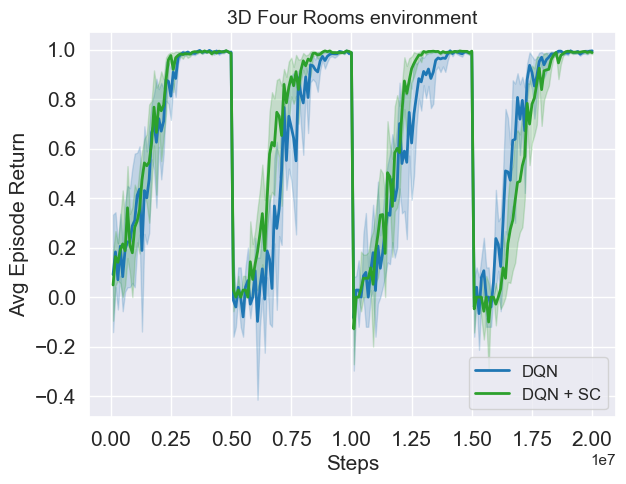

In [27]:
"""
This plot is to show how adding consolidation to Q-values are not very effective
"""

f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("3D Four Rooms environment", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Avg Episode Return", fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms_slippery" + "_consolidating_only_qvalues"
plt.savefig(filename + ".pdf")
plt.show()

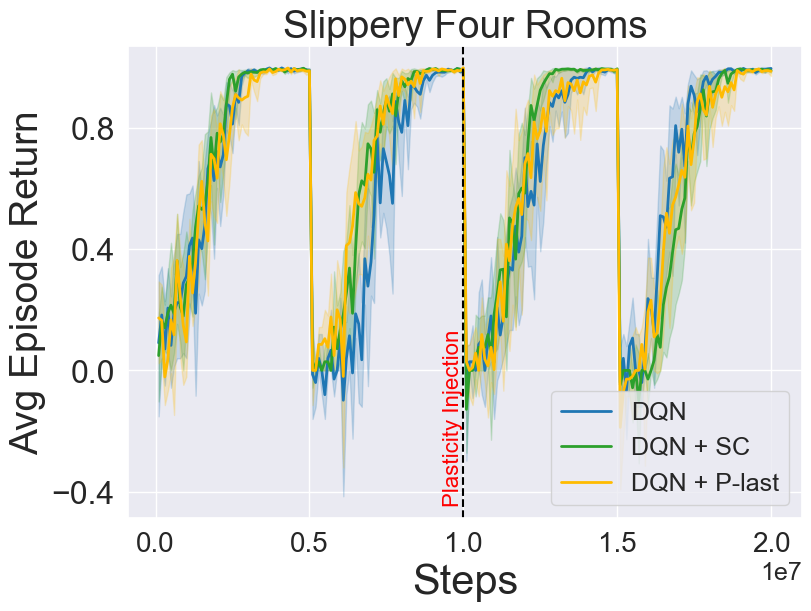

In [28]:
"""
This plot is to show how compare injecting plasticity vs consolidation to Q-values
"""

from matplotlib.ticker import MaxNLocator

f, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

xline = 1e7
ymin, ymax = ax.get_ylim()

# draw the vertical line
plt.axvline(x=xline, color="black", linestyle="--", linewidth=1.5)

# add the text
plt.text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin), # 40% above the bottom
    "Plasticity Injection",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=16
)

plt.title("Slippery Four Rooms", fontsize=28)
plt.xlabel("Steps", fontsize=30)
plt.ylabel("Avg Episode Return", fontsize=28)
plt.legend(loc="lower right", fontsize=18)
plt.xticks(fontsize=20)
plt.yticks(fontsize=23)
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # ~5 ticks
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().xaxis.get_offset_text().set_fontsize(18)
filename = "avg_episode_returns_training_plot_slippery_four_rooms" + "_plasticity_injection_vs_consolidation_q_values"
plt.savefig(filename + ".pdf")
plt.show()

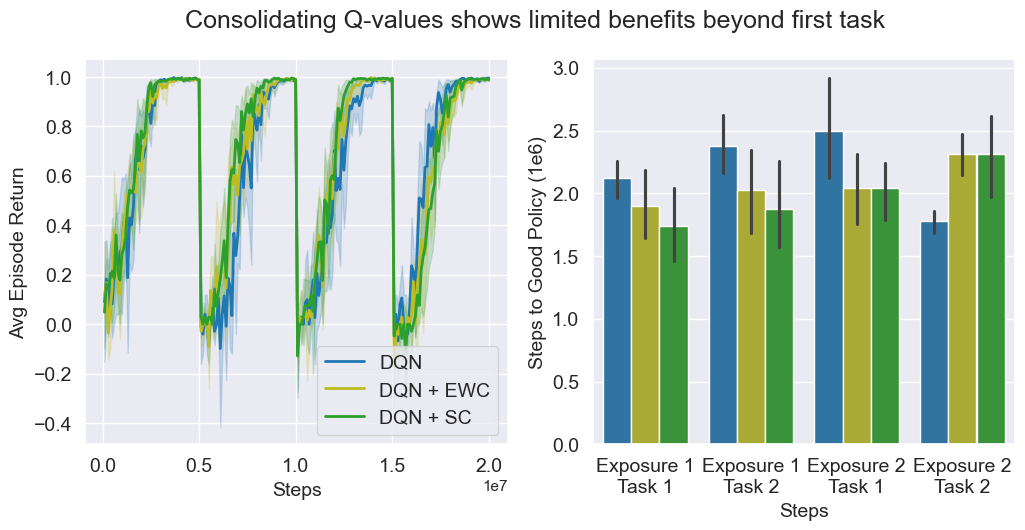

<Figure size 1400x1000 with 0 Axes>

In [29]:
"""
This plot is to compare the various consolidation techniques on Q-values
"""


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)


sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + EWC",
    "DQN + SC",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
plt.figure(figsize=(14, 10))
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

fig.suptitle("Consolidating Q-values shows limited benefits beyond first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=14)
axes[0].set_ylabel("Avg Episode Return", fontsize=14)
axes[0].tick_params(axis="x", labelsize=14)
axes[0].tick_params(axis="y", labelsize=14)
axes[0].legend(loc="lower right", fontsize=14)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("Steps", fontsize=14)
axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=14)
axes[1].tick_params(axis="x", labelsize=14)
axes[1].tick_params(axis="y", labelsize=14)
axes[1].legend_.remove()

filename = "consolidating_q_values_only_analysis_fourrooms_slippery"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()

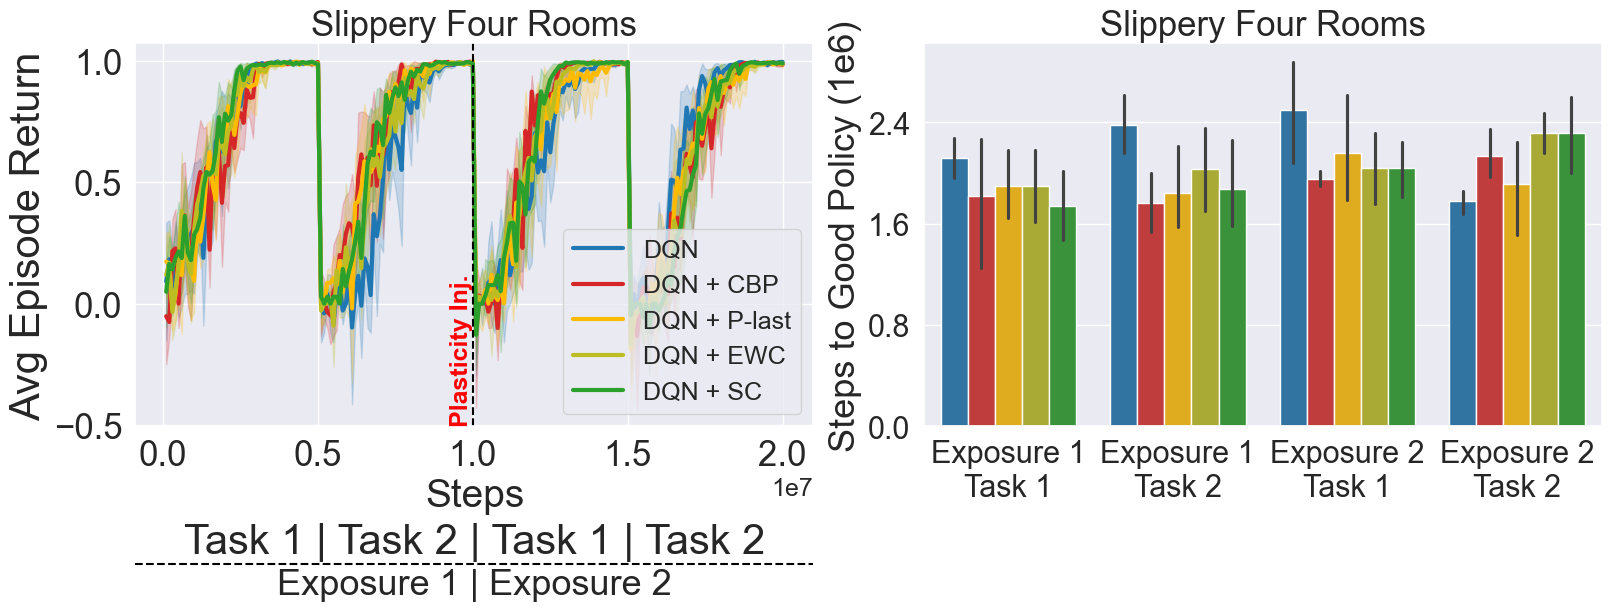

In [30]:
"""
This plot is to compare the plasticity injection vs consolidation on the Q-values
"""


fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_cbp"]],
    label=agents_new_names["dqn_cbp"],
    color=color_code[agents_new_names["dqn_cbp"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000
xline = 1e7

agent_order = [
    "DQN",
    "DQN + CBP",
    "DQN + P-last",
    "DQN + EWC",
    "DQN + SC",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

# fig.suptitle("Slippery Four Rooms: Plasticity-Stability Analysis", fontsize=30)

ymin, ymax = axes[0].get_ylim()

axes[0].set_title("Slippery Four Rooms", fontsize=25)
axes[0].set_xlabel("Steps", fontsize=28)
axes[0].set_ylabel("Avg Episode Return", fontsize=30)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].legend(loc="lower right", fontsize=18)
axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18,
    fontweight="bold"
)
axes[0].xaxis.get_offset_text().set_fontsize(18)

# axes[0].text(-0.1, 1.10, "(a)", transform=axes[0].transAxes,
#              fontsize=25, fontweight="bold", va="top", ha="right")
#
#
# axes[1].text(-0.1, 1.10, "(b)", transform=axes[1].transAxes,
#              fontsize=25, fontweight="bold", va="top", ha="right")

axes[0].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=30
)

axes[0].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[0].transAxes, clip_on=False
)

axes[0].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=26
)


axes[1].set_title("Slippery Four Rooms", fontsize=25)
axes[1].set_xlabel("")
axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=26)
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].legend_.remove()
axes[1].yaxis.get_offset_text().set_fontsize(18)
axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))

filename = "consolidation_vs_plasticity_injection_qvalues_analysis_fourrooms_slippery"
plt.savefig(filename + ".pdf")
plt.show()




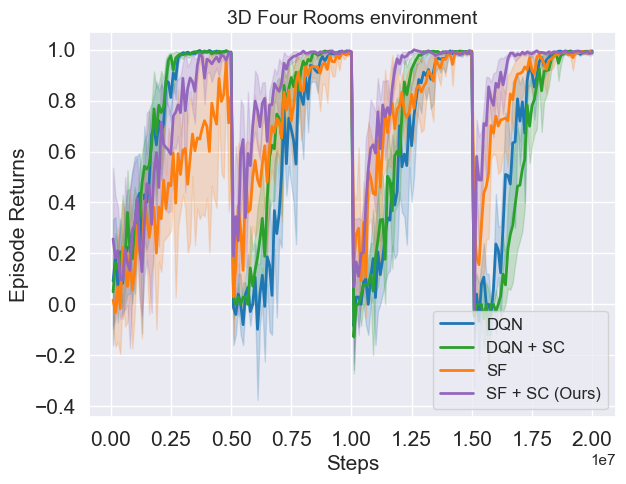

In [31]:
f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("3D Four Rooms environment", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Episode Returns", fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms_slippery" + "_consolidating_sf_leads_to_improvements"
plt.savefig(filename + ".pdf")
plt.show()

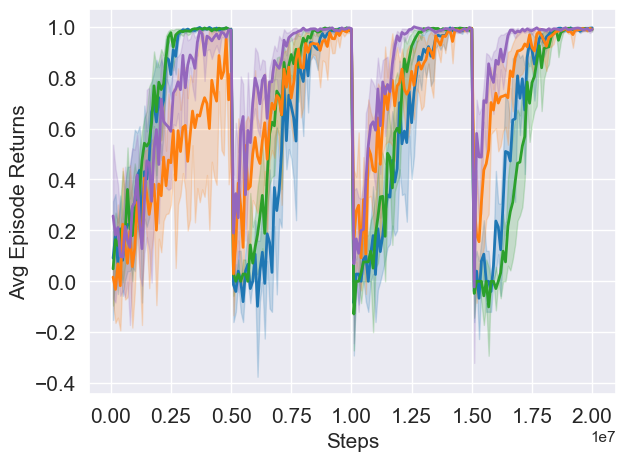

In [32]:
f, ax = plt.subplots(figsize=(6.8, 5))

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label="Non-Predictive",
    color=color_code[agents_new_names["dqn"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label="Non-Predictive + SC",
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label="Predictive",
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label="Predictive + SC",
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

plt.title("", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Avg Episode Returns", fontsize=15)
# plt.legend(loc="lower right", fontsize=12)
plt.legend().set_visible(False)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
filename = "avg_episode_returns_training_plot_fourrooms_slippery" + "_consolidating_sf_leads_to_improvements_simplified"
plt.savefig(filename + ".pdf")
plt.show()

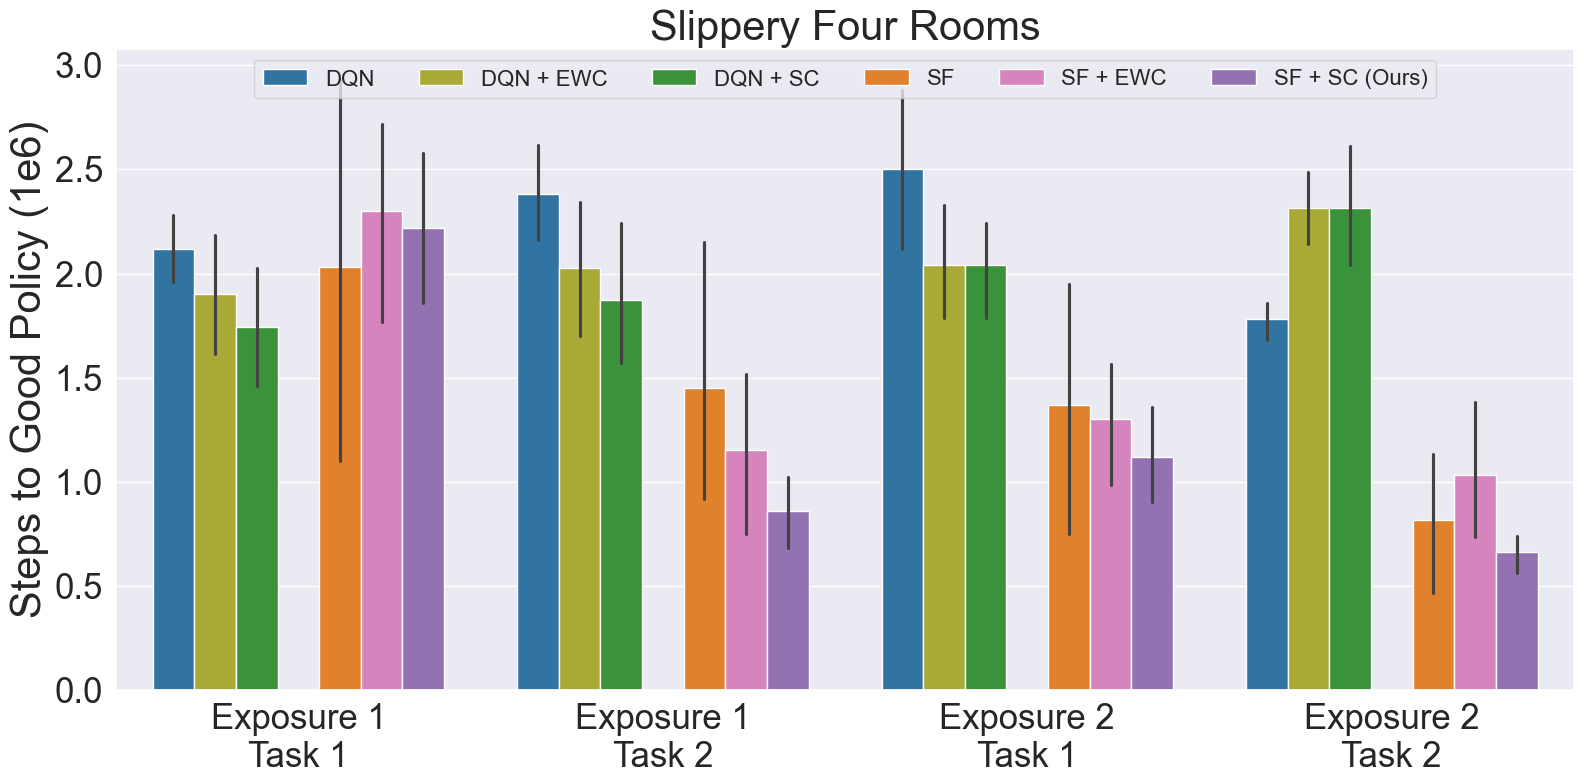

In [33]:
rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF",
    "SF + EWC",
    "SF + SC (Ours)",
]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
)
# Remove spacer from legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[h for h, l in zip(handles, labels) if l != " "],
          labels=[l for l in labels if l != " "],
          title=None, loc="upper center", fontsize=16, ncol=len(agent_order))

ax.yaxis.get_offset_text().set_visible(False)
plt.title("Slippery Four Rooms", fontsize=30)
plt.ylabel("Steps to Good Policy (1e6)", fontsize=30)
plt.xlabel("", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
filename = "Steps_to_good_policy_fourrooms_slippery"
plt.savefig(filename + ".pdf")
plt.tight_layout()
plt.show()


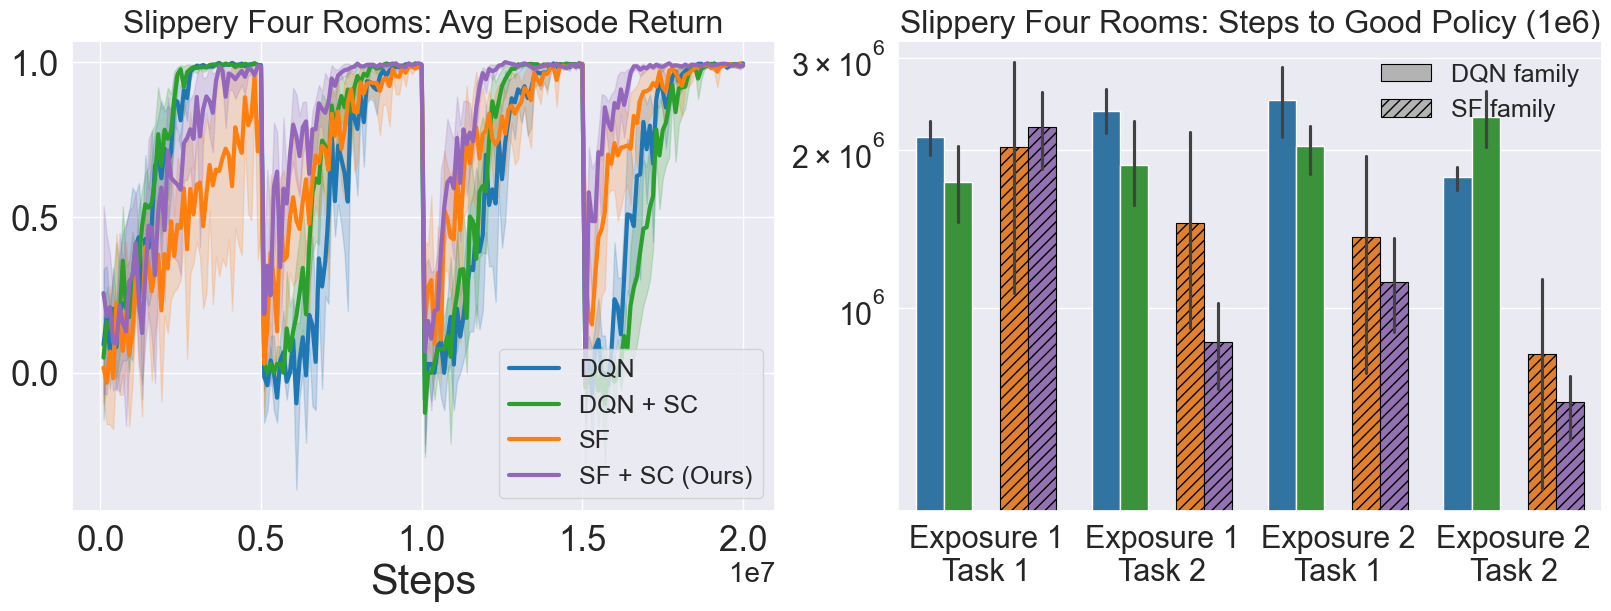

In [34]:
from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + SC",
    " ",
    "SF",
    "SF + SC (Ours)",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

x_order = ["Exposure 1\nTask 1", "Exposure 1\nTask 2",
           "Exposure 2\nTask 1", "Exposure 2\nTask 2"]

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    order=x_order,
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

# for i, bar in enumerate(axes[1].patches):
#     print(i, bar.get_x(), bar.get_height())

sf_set = {"SF", "SF + SC (Ours)"}  # only hatch SF
patterns = {"SF": "///", "SF + SC (Ours)": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        # print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

# Create two dummy handles
# 1) Build the small “style” legend
plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="DQN family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SF family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper right", frameon=False, fontsize=18)

# fig.suptitle("Consolidating Successor Features mitigates forgetting beyond the first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=14)
axes[0].set_title("Slippery Four Rooms: Avg Episode Return", fontsize=23)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].legend(loc="lower right", fontsize=18)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Slippery Four Rooms: Steps to Good Policy (1e6)", fontsize=23)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "consolidating_q_values_vs_sf_analysis_slippery_fourrooms"
plt.savefig(filename + ".pdf")
plt.show()

Bar: task=Exposure 1
Task 1, agent=DQN + EWC, height=1900000.0
Bar: task=Exposure 1
Task 2, agent=DQN + EWC, height=2028571.4285714286
Bar: task=Exposure 2
Task 1, agent=DQN + EWC, height=2042857.142857143
Bar: task=Exposure 2
Task 2, agent=DQN + EWC, height=2314285.714285714
Bar: task=Exposure 1
Task 1, agent=DQN + SC, height=1742857.142857143
Bar: task=Exposure 1
Task 2, agent=DQN + SC, height=1871428.5714285714
Bar: task=Exposure 2
Task 1, agent=DQN + SC, height=2042857.142857143
Bar: task=Exposure 2
Task 2, agent=DQN + SC, height=2314285.714285714
Bar: task=Exposure 1
Task 1, agent=SF + EWC, height=2300000.0
Bar: task=Exposure 1
Task 2, agent=SF + EWC, height=1150000.0
Bar: task=Exposure 2
Task 1, agent=SF + EWC, height=1300000.0
Bar: task=Exposure 2
Task 2, agent=SF + EWC, height=1033333.3333333334
Bar: task=Exposure 1
Task 1, agent=SF + SC (Ours), height=2220000.0
Bar: task=Exposure 1
Task 2, agent=SF + SC (Ours), height=860000.0
Bar: task=Exposure 2
Task 1, agent=SF + SC (Ours),

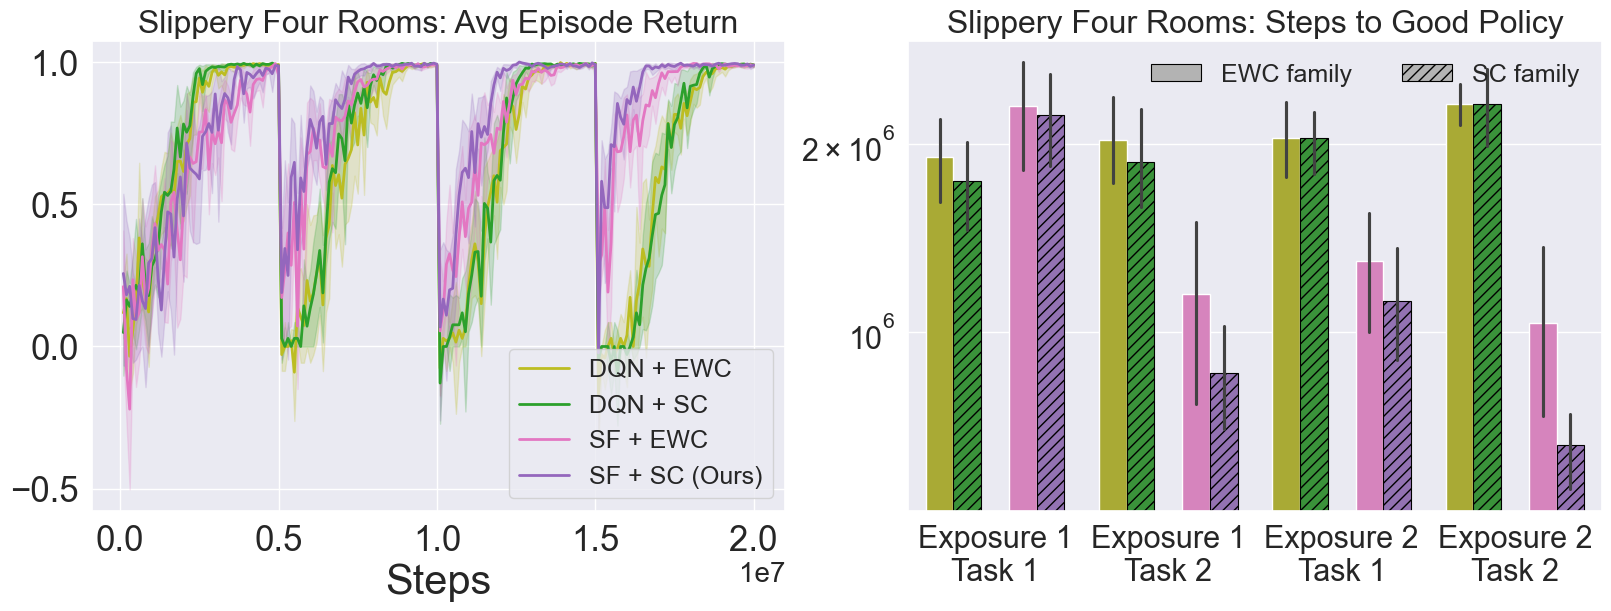

In [35]:
"""
This plot is to compare synaptic consolidation vs EWC
"""


fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_online_ewc"]],
    label=agents_new_names["simple_sf_online_ewc"],
    color=color_code[agents_new_names["simple_sf_online_ewc"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF + EWC",
    "SF + SC (Ours)",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

sf_set = {"DQN + SC", "SF + SC (Ours)"}  # only hatch SC
patterns = {"DQN + SC": "///", "SF + SC (Ours)": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

# fig.suptitle("Comparison of Synaptic and Elastic Weight Consolidation", fontsize=18)

plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="EWC family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SC family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper right", frameon=False, fontsize=18, ncol=2)

# axes[0].set_xlabel("Steps", fontsize=14)
# axes[0].set_ylabel("Avg Episode Return", fontsize=14)
# axes[0].tick_params(axis="x", labelsize=14)
# axes[0].tick_params(axis="y", labelsize=14)
# axes[0].legend(loc="lower right")
#
#
# axes[1].yaxis.get_offset_text().set_visible(False)
# axes[1].set_xlabel("")
# axes[1].set_ylabel("Steps to Good Policy (1e6)", fontsize=14)
# axes[1].tick_params(axis="x", labelsize=14)
# axes[1].tick_params(axis="y", labelsize=14)

axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=14)
axes[0].set_title("Slippery Four Rooms: Avg Episode Return", fontsize=23)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].legend(loc="lower right", fontsize=18)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Slippery Four Rooms: Steps to Good Policy", fontsize=23)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "ewc_vs_synaptic_consolidation_slippery_fourrooms"
plt.savefig(filename + ".pdf")
plt.show()

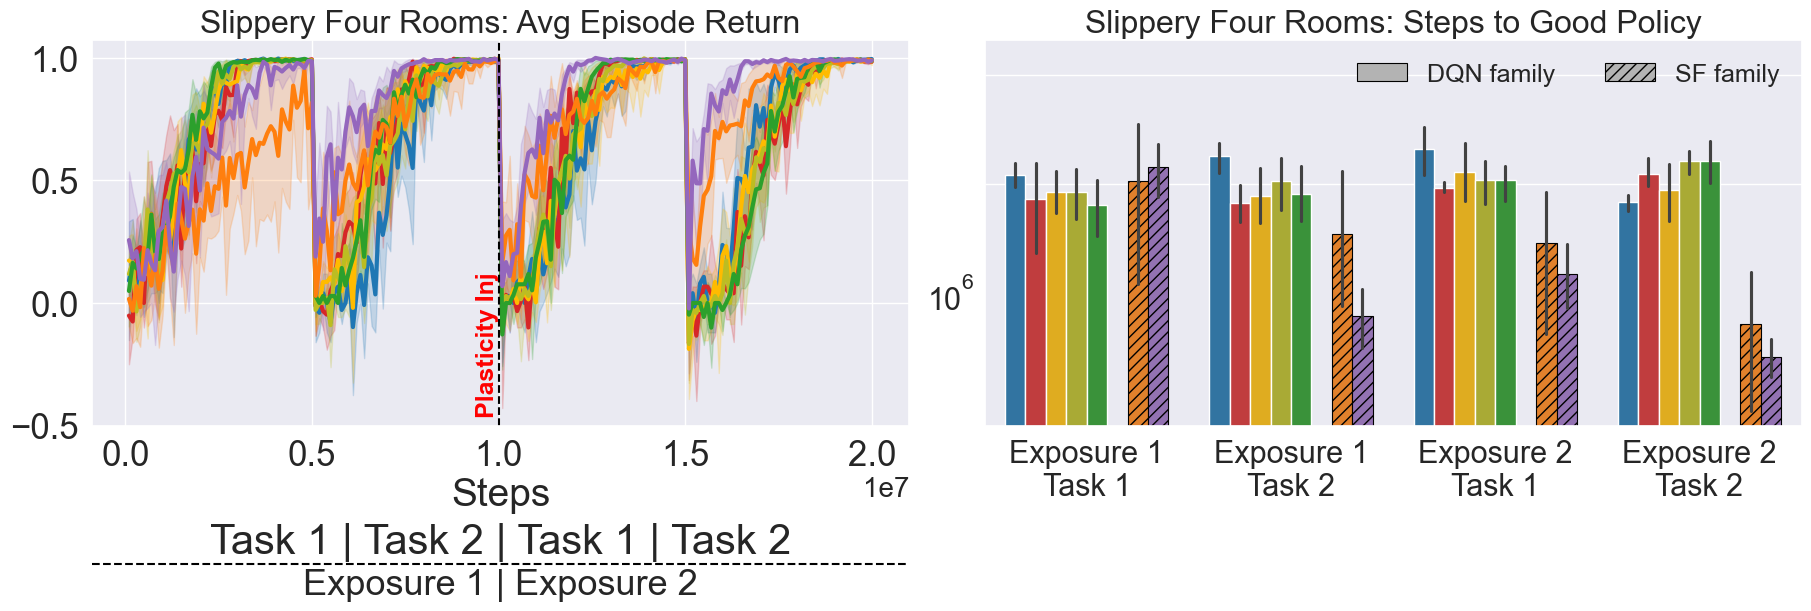

In [41]:
from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn"]],
    label=agents_new_names["dqn"],
    color=color_code[agents_new_names["dqn"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_cbp"]],
    label=agents_new_names["dqn_cbp"],
    color=color_code[agents_new_names["dqn_cbp"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_plasticity_injection"]],
    label=agents_new_names["DQN_plasticity_injection"],
    color=color_code[agents_new_names["DQN_plasticity_injection"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["dqn_online_ewc"]],
    label=agents_new_names["dqn_online_ewc"],
    color=color_code[agents_new_names["dqn_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["DQN_consolidation_params_continuous"]],
    label=agents_new_names["DQN_consolidation_params_continuous"],
    color=color_code[agents_new_names["DQN_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5,
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["simple_sf_agent"]],
    label=agents_new_names["simple_sf_agent"],
    color=color_code[agents_new_names["simple_sf_agent"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/steps",
    y="eval/episode_return",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_consolidation_params_continuous"]],
    label=agents_new_names["sf_consolidation_params_continuous"],
    color=color_code[agents_new_names["sf_consolidation_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


rows = []
threshold = 1000
aggregate_across_runs = True  # set True to average across runs/seeds
num_train_steps_per_task = 5000000

agent_order = [
    "DQN",
    "DQN + CBP",
    "DQN + P-last",
    "DQN + EWC",
    "DQN + SC",
    " ",
    "SF",
    "SF + SC (Ours)",

]

task_labels = {
    0: "Exposure 1\nTask 1",
    1: "Exposure 1\nTask 2",
    2: "Exposure 2\nTask 1",
    3: "Exposure 2\nTask 2",
}

for run_idx, (temp, cfg, name) in enumerate(zip(summary_list, config_list, name_list)):
    steps = np.asarray(temp["eval/steps"])
    tasks = np.asarray(temp["train/task"])
    mavg = np.asarray(temp["eval/avg_episode_length"])

    # Sanity check: lengths should match
    L = min(len(steps), len(tasks), len(mavg))
    steps, tasks, mavg = steps[:L], tasks[:L], mavg[:L]

    for task_id in np.unique(tasks):
        idxs = np.where(tasks == task_id)[0]
        if idxs.size == 0:
            continue

        # earliest idx within this task where condition is true
        hit_mask = mavg[idxs] < threshold
        if hit_mask.any():
            first_idx = idxs[np.argmax(hit_mask)]  # index in the *full* arrays
            global_step = steps[first_idx]
            local_step = global_step - task_id * num_train_steps_per_task

        else:
            first_idx = None
            global_step = np.nan
            local_step = np.nan

        rows.append({
            "run_idx": run_idx,
            "run_name": name,
            "agent_name": cfg.get("agent_name", f"run{run_idx}"),
            "task": task_id,
            "threshold": threshold,
            "first_below_global": global_step,
            "first_below_local": local_step,   # << use this for plotting
        })

df_hits = pd.DataFrame(rows)
df_hits["Agent"] = df_hits["agent_name"].map(agents_new_names)
df_hits["task_label"] = df_hits["task"].map(task_labels)
palette = {name: color_code[name] for name in df_hits["Agent"].unique() if name in color_code}
palette_with_space = palette.copy()
palette_with_space[" "] = (0, 0, 0, 0)   # transparent color


# Optional: ensure tasks are ordered nicely (0..3 or custom)
# df_hits["task"] = pd.Categorical(df_hits["task"], ordered=True)

x_order = ["Exposure 1\nTask 1", "Exposure 1\nTask 2",
           "Exposure 2\nTask 1", "Exposure 2\nTask 2"]

# === Plotting ===
sns.barplot(
    data=df_hits,
    x="task_label",
    y="first_below_local",
    order=x_order,
    hue="Agent",
    dodge=True,
    estimator="mean",   # now mean per agent_name per task
    errorbar="ci",
    palette=palette_with_space,
    hue_order=agent_order,
    ax=axes[1],
)

# for i, bar in enumerate(axes[1].patches):
#     print(i, bar.get_x(), bar.get_height())

sf_set = {"SF", "SF + SC (Ours)"}  # only hatch SF
patterns = {"SF": "///", "SF + SC (Ours)": "///"}  # mapping Agent -> hatch pattern

patch_iter = iter(axes[1].patches)
for x in agent_order:
    for h in x_order:
        if x == " ":
            continue
        # check if this combo exists in the data
        if df_hits[(df_hits["task_label"] == h) & (df_hits["Agent"] == x)].empty:
            continue
        bar = next(patch_iter)
        if x in sf_set:
            bar.set_hatch(patterns[x])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
        # print(f"Bar: task={h}, agent={x}, height={bar.get_height()}")

# Create two dummy handles
# 1) Build the small “style” legend
plain_patch  = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                              label="DQN family")
hatched_patch = mpatches.Patch(facecolor="0.7", edgecolor="black", linewidth=0.8,
                               hatch="///", label="SF family")

# 3) Add the legend INSIDE the axes first (to confirm it shows)
axes[1].legend(handles=[plain_patch, hatched_patch],
               title=None, loc="upper right", frameon=False, fontsize=18, ncol=2)

# fig.suptitle("Consolidating Successor Features mitigates forgetting beyond the first task", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=28)
axes[0].set_ylabel("", fontsize=14)
axes[0].set_title("Slippery Four Rooms: Avg Episode Return", fontsize=23)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
# axes[0].legend(loc="lower right", fontsize=20, ncols=2)
axes[0].legend().set_visible(False)
axes[0].xaxis.get_offset_text().set_fontsize(20)

ymin, ymax = axes[0].get_ylim()
axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.4 * (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18,
    fontweight="bold"
)

axes[0].text(
    0.5, -0.25,
    "Task 1 | Task 2 | Task 1 | Task 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=30
)

axes[0].hlines(
    y=-0.36, xmin=0, xmax=1,
    colors="black", linestyles="--", linewidth=1.5,
    transform=axes[0].transAxes, clip_on=False
)

axes[0].text(
    0.5, -0.37,
    "Exposure 1 | Exposure 2",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=26
)

axes[1].yaxis.get_offset_text().set_visible(False)
axes[1].set_xlabel("")
axes[1].set_ylabel("", fontsize=28)
axes[1].set_title("Slippery Four Rooms: Steps to Good Policy", fontsize=23)
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", labelsize=22)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks
axes[1].set_ylim(top=5 * (10**6))

filename = "plasticity_sc_comparison_slippery_fourrooms_ou"
plt.savefig(filename + ".pdf")
plt.show()

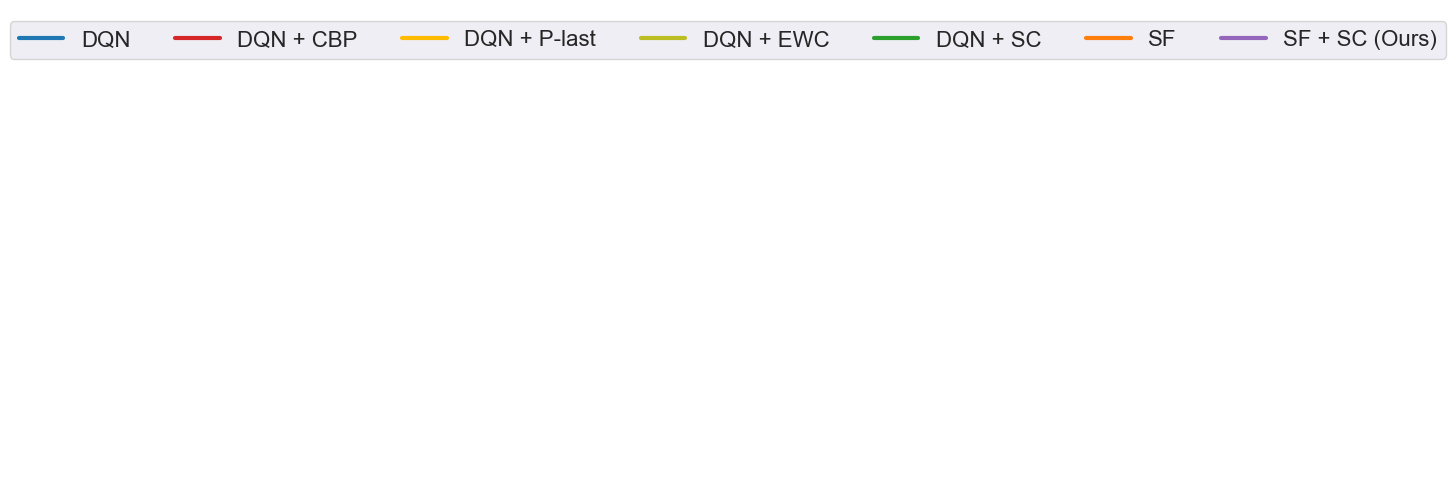

In [38]:
"""
This plot is only used for making legends!!!!
"""

from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color=color_code[agents_new_names["dqn"]], lw=3, label=agents_new_names["dqn"]),
    Line2D([0], [0], color=color_code[agents_new_names["dqn_cbp"]], lw=3, label=agents_new_names["dqn_cbp"]),
    Line2D([0], [0], color=color_code[agents_new_names["DQN_plasticity_injection"]], lw=3, label=agents_new_names["DQN_plasticity_injection"]),
    Line2D([0], [0], color=color_code[agents_new_names["dqn_online_ewc"]], lw=3, label=agents_new_names["dqn_online_ewc"]),
    Line2D([0], [0], color=color_code[agents_new_names["DQN_consolidation_params_continuous"]], lw=3, label=agents_new_names["DQN_consolidation_params_continuous"]),
    Line2D([0], [0], color=color_code[agents_new_names["simple_sf_agent"]], lw=3, label=agents_new_names["simple_sf_agent"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_consolidation_params_continuous"]], lw=3, label=agents_new_names["sf_consolidation_params_continuous"]),
]

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis("off")               # hide axes
plt.legend(
    handles=custom_lines,
    loc="upper center",          # center horizontally
    bbox_to_anchor=(0.5, 1),
    fontsize=16,
    ncol=8                       # optional: make legend entries spread in columns
)

filename = "four_rooms_make_title"
fig.savefig(filename + ".pdf")
plt.show()
